In [1]:
#CLEANED

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from matplotlib.ticker import FuncFormatter

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from scipy.stats import shapiro, levene, rankdata, linregress, kruskal
from statsmodels.stats.anova import anova_lm
from scipy.stats import f_oneway
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.cm import Blues, Reds
from matplotlib.lines import Line2D


import helper

/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:108: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = windows.dot(grn)
/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:131: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = gene_vals.dot(internal_grn)


In [ ]:
#Checking evolved fitness values against features of target patterns ------------------

root1="~/CA_GRN_results/non_detailed_save/extra_inputs/"
root2="~/CA_GRN_results/non_detailed_save/"
root3="~/CA_GRN_results/detailed_save/"
season_len = 300
rules = [22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]
seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
num_cells = 22
dev_steps = 22
grn_size = 22
geneid = 1
num_reps = 15

metric = "maxfits" #rerun below for "avefits" as well

maxxs = []
maxys = []

ones_1=[]
ones_2=[]
perc_overlaps=[]
stat_end_1 = []
stat_end_2 = []

pop = np.random.randn(1000, grn_size+2, grn_size).astype(np.float64) #For comparision to random GRNs

data = []
ave_pss=[]
ave_rand = []
for idx, seed_ints in enumerate(seed_intss):
    for rule in rules:

        #Info about target
        start_patternA = helper.seedID2string(seed_ints[0], num_cells)
        start_patternB = helper.seedID2string(seed_ints[1], num_cells)
        targetA = helper.rule2targets_wrapped_wstart(rule, L=dev_steps+1, N=num_cells, start_pattern=start_patternA)
        targetB = helper.rule2targets_wrapped_wstart(rule, L=dev_steps+1, N=num_cells, start_pattern=start_patternB)

        #Random GRN success
        _,_, rand_fitnesses1 = helper.get_pop_TPF(pop, 1000, num_cells, grn_size, dev_steps, geneid, rule, seed_ints[0],seed_ints[0])
        _,_, rand_fitnesses2 = helper.get_pop_TPF(pop, 1000, num_cells, grn_size, dev_steps, geneid, rule, seed_ints[1],seed_ints[1])
        ave_rand.append((max(rand_fitnesses1) + max(rand_fitnesses2))/2)

        #Target pattern features
        ones_1.append(sum(targetA).sum()/(num_cells*(dev_steps+1)))
        ones_2.append(sum(targetB).sum()/(num_cells*(dev_steps+1)))
        where_overlap = np.where(targetA==targetB)
        perc_overlaps.append(len(targetA[where_overlap])/(22*23))

        #Get evolved data
        if idx == 0:
            root=root3
        elif idx == 1:
            root=root2
        else:
            root=root1
        vari_maxs, env1_maxs, env2_maxs=helper.get_fits([rule,rule], seed_ints, metric, root, season_len, num_reps, id_start = 0)
        vari_maxs=[v[:9600] for v in vari_maxs] #chopped end to have the same number of generations in both alternative environments
        env1_maxs=[v[:9600] for v in env1_maxs]
        env2_maxs=[v[:9600] for v in env2_maxs]
        
        stat_end_1.append(np.array(env1_maxs)[:,-1].mean())
        stat_end_2.append(np.array(env2_maxs)[:,-1].mean())
    
        d,c,ps,lists = helper.scatter_value(vari_maxs, env1_maxs, env2_maxs, season_len=300) #get difference between static and variable runs
        for i in range(num_reps): #list1, list2, static1, static2
            data.append({'CA': str(rule), 'Seed': str(seed_ints), 'Env': "vari1", 'Val': lists[0][i]})
            data.append({'CA': str(rule), 'Seed': str(seed_ints), 'Env': "vari2", 'Val': lists[1][i]})
            data.append({'CA': str(rule), 'Seed': str(seed_ints), 'Env': "static1", 'Val': lists[2][i]})
            data.append({'CA': str(rule), 'Seed': str(seed_ints), 'Env': "static2", 'Val': lists[3][i]})

        ave_pss.append(ps)
        maxxs.append(d[0])
        maxys.append(d[1])
df = pd.DataFrame(data)

In [3]:
def quick_plot(xs,ys,myxlab, myylab):
    plt.scatter(xs,ys)
    slope, intercept, r_value, p_value, std_err = linregress(xs, ys)
    x_fit = np.linspace(min(xs), max(xs), 100)
    plt.xlabel(myxlab)
    plt.ylabel(myylab)
    # r_value: The Pearson correlation coefficient. The square of rvalue is equal to the coefficient of determination (R^2).
    print("slope: ", slope, "R-squared: ", r_value**2, "P: ", p_value)
    plt.show()

slope:  -0.06742706046181567 R-squared:  0.05531753849999029 P:  0.015727268112217092


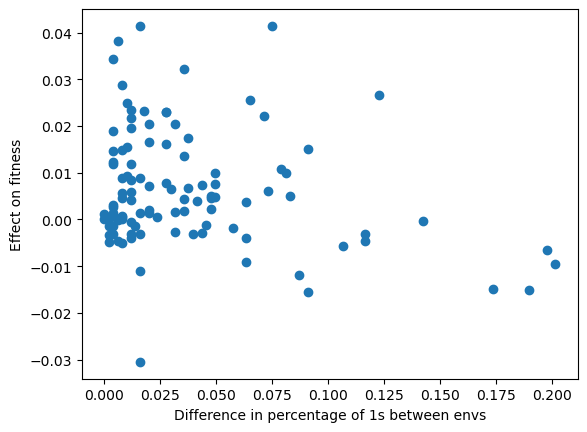

slope:  0.0013869119672690676 R-squared:  0.0001195289544839526 P:  0.9118610284798669


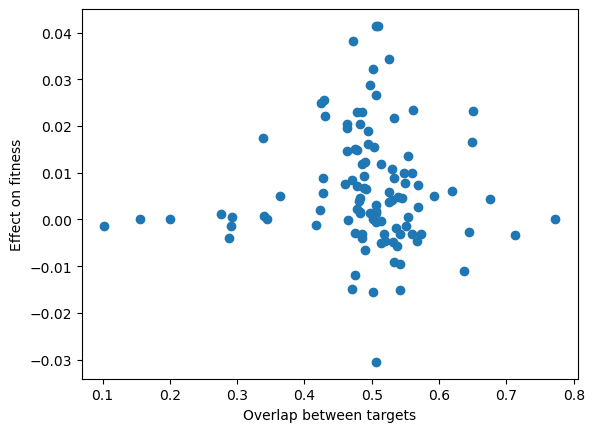

slope:  -0.025619757672374233 R-squared:  0.05435016949204867 P:  0.01669459316407813


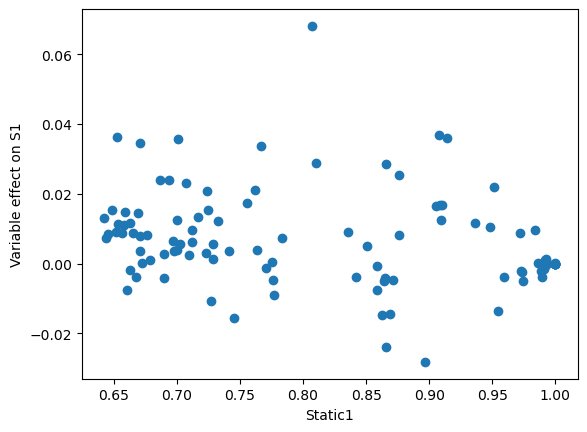

slope:  -0.020366699548825407 R-squared:  0.01913563868423595 P:  0.15934286898785593


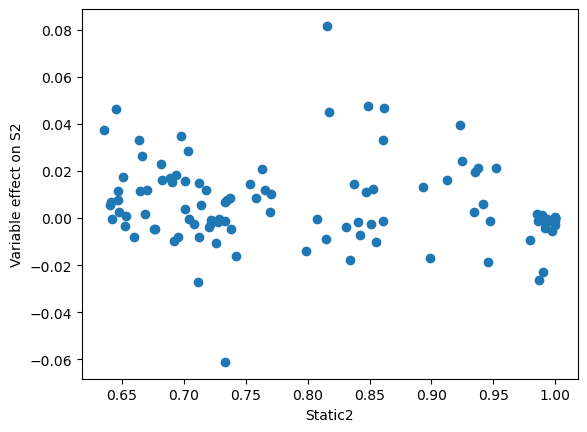

slope:  -0.016922515864285576 R-squared:  0.02693882197432696 P:  0.09431326566223033


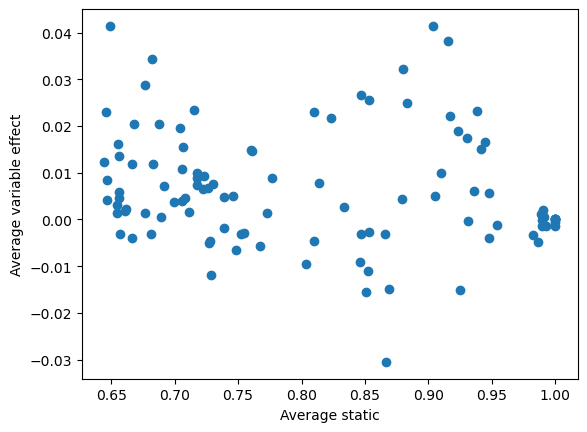

slope:  -0.044783539119264734 R-squared:  0.031112394723914895 P:  0.0718710232020829


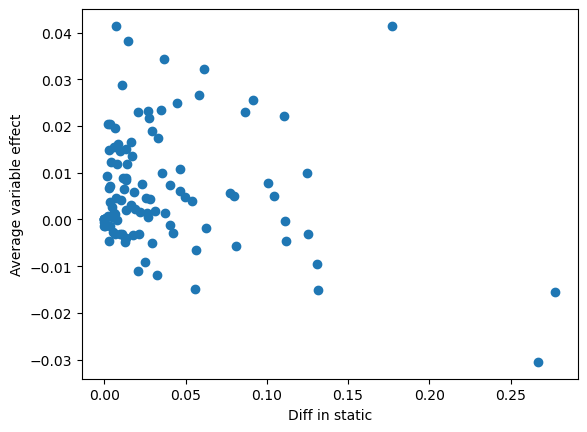

In [4]:
quick_plot(abs(np.array(ones_2)-np.array(ones_1)),(np.array(maxxs)+np.array(maxys))/2, myxlab="Difference in percentage of 1s between envs", myylab="Effect on fitness")
#No relationship

quick_plot(perc_overlaps,(np.array(maxxs)+np.array(maxys))/2, myxlab="Overlap between targets", myylab="Effect on fitness")
#No relationship

quick_plot(np.array(stat_end_1),np.array(maxxs), myxlab="Static1", myylab="Variable effect on S1")
#No relationship

quick_plot(np.array(stat_end_2),np.array(maxys), myxlab="Static2", myylab="Variable effect on S2")
#No relationship

quick_plot((np.array(stat_end_1)+np.array(stat_end_2))/2,(np.array(maxys)+np.array(maxxs))/2, myxlab="Average static", myylab="Average variable effect")
#No relationship with maxfit
#Weak relationship with avefit, the higher the average fitness of the static, the lower the fitness gain from the variability

quick_plot(np.abs(np.array(stat_end_1)-np.array(stat_end_2)),(np.array(maxxs)+np.array(maxys))/2, myxlab="Diff in static", myylab="Average variable effect")
#No relationship


In [ ]:
#Statistics on variables affecting fitness - CA rule, initial condition, environmental variability

#Everything was repeated independently for the two seasons, and also for average fitness / maximum fitness
temp_df = df[(df["Env"]=="static1") | (df["Env"]=="vari1")] 

data_groups=[]
for t in list(set(temp_df["Env"].to_list())): #Split by static vs variable
    tl = temp_df[temp_df["Env"]==str(t)].Val.to_list()
    data_groups.append(tl)

#Check if paramteric test can be used

print("Shapiro-Wilk Test for Normality:")
for i, group in enumerate(data_groups, start=1):
    stat, p = shapiro(group)
    print(f"Group {i}: W={stat:.3f}, p={p:.3f}")
    if p > 0.05:
        print(f"  Group {i} follows a normal distribution (p > 0.05).")
    else:
        print(f"  Group {i} does not follow a normal distribution (p ≤ 0.05).")

print("\nLevene's Test for Homogeneity of Variances:")
stat, p = levene(*data_groups)
print(f"Levene's statistic={stat:.3f}, p={p:.3f}")
if p > 0.05:
    print("Variances are homogeneous (p > 0.05).")
else:
    print("Variances are not homogeneous (p ≤ 0.05).")

#Effect of environmental variability alone

stat, p = kruskal(*data_groups)
print("\nKruskal-Wallis H-test p-value: ",p)
print("\nOne-way ANOVA: ",f_oneway(*data_groups))

#Effect of environmental variability in combination with CA rule

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

temp_df.loc[:, 'rank'] = rankdata(temp_df['Val']) # Rank the data for non-parametric ANOVA
model = ols('rank ~ C(CA) + C(Env) + C(CA):C(Env)', data=temp_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n", anova_table)


Shapiro-Wilk Test for Normality:
Group 1: W=0.887, p=0.000
  Group 1 does not follow a normal distribution (p ≤ 0.05).
Group 2: W=0.888, p=0.000
  Group 2 does not follow a normal distribution (p ≤ 0.05).

Levene's Test for Homogeneity of Variances:
Levene's statistic=0.591, p=0.442
Variances are homogeneous (p > 0.05).

Kruskal-Wallis H-test p-value:  0.05509775774529417

One-way ANOVA:  F_onewayResult(statistic=2.26507383282645, pvalue=0.13242022820033494)

                     sum_sq      df           F    PR(>F)
C(CA)         1.994557e+09    14.0  735.310821  0.000000
C(Env)        3.042670e+06     1.0   15.703897  0.000076
C(CA):C(Env)  2.144453e+06    14.0    0.790571  0.680556
Residual      6.045079e+08  3120.0         NaN       NaN


In [6]:
#Effect of CA rule

n=len(rules)
groups_xs = []
groups_ys = []
for i in range(n):
    groups_xs.append(maxxs[i::n])
    groups_ys.append(maxys[i::n])

data_groups = np.array(groups_xs)
stat, p = kruskal(*data_groups)
print("\nCA rule, season 1")
print("Kruskal-Wallis H-test p-value: ",p)

data_groups = np.array(groups_ys)
stat, p = kruskal(*data_groups)
print("\nCA rule, season 2")
print("Kruskal-Wallis H-test p-value: ",p)

data_groups =(np.array(groups_xs) + groups_ys)/2
stat, p = kruskal(*data_groups)
print("\nCA rule, averaged across seasons")
print("Kruskal-Wallis H-test p-value: ",p)

#Effect of initial condition

n=len(rules)
groups_xs = []
groups_ys = []
for i in range(len(seed_intss)):
    groups_xs.append(maxxs[n*i:n*(i+1)])
    groups_ys.append(maxys[n*i:n*(i+1)])

data_groups = np.array(groups_xs)
stat, p = kruskal(*data_groups)
print("\nInitial condition, season 1")
print("Kruskal-Wallis H-test p-value: ",p)

data_groups = np.array(groups_ys)
stat, p = kruskal(*data_groups)
print("\nInitial condition, season 2")
print("Kruskal-Wallis H-test p-value: ",p)

data_groups =(np.array(groups_xs) + groups_ys)/2
stat, p = kruskal(*data_groups)
print("\nInitial condition, averaged across seasons")
print("Kruskal-Wallis H-test p-value: ",p)


CA rule, season 1
Kruskal-Wallis H-test p-value:  0.018355379552241053

CA rule, season 2
Kruskal-Wallis H-test p-value:  0.004735440003600835

CA rule, averaged across seasons
Kruskal-Wallis H-test p-value:  0.0007149039261810503

Initial condition, season 1
Kruskal-Wallis H-test p-value:  0.03013061079483374

Initial condition, season 2
Kruskal-Wallis H-test p-value:  0.12258122735032076

Initial condition, averaged across seasons
Kruskal-Wallis H-test p-value:  0.17275712086400316


/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


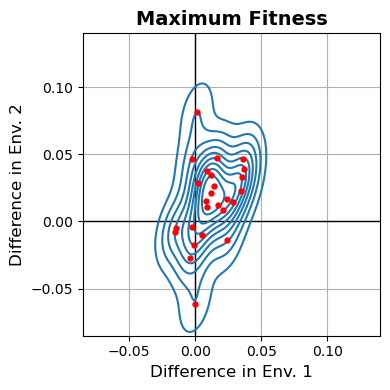

In [ ]:
#Checking average fitness and maximum fitness change due to environmental variability, accounting also for multiple testing

fig, ax0 = plt.subplots(figsize=(4, 4), ncols=1, sharex=True, sharey=True)

def unzip(l):
    return list(zip(*l))

alpha_sig = 0.05
max_adjusted_pvalues = multipletests(np.array(ave_pss).flatten(), method='fdr_bh')[1]
max_adjusted_pvalues = max_adjusted_pvalues.reshape(105,2)

kwargs = {"color":"red", "alpha":1, "s":50, "zorder":2}

max_sig_xs, max_sig_ys = unzip([(x,y) for (env1, env2),x,y in zip(max_adjusted_pvalues, maxxs, maxys) if env1 < alpha_sig or env2 < alpha_sig])
sns.kdeplot(x = max_sig_xs, y = max_sig_ys, ax=ax0,fill=False)
for (env1, env2),x,y in zip(max_adjusted_pvalues, maxxs, maxys):
        cwargs = dict(kwargs)
        if env1 < alpha_sig or env2 < alpha_sig:
                ax0.scatter(x,y,marker=".", **cwargs)


ax0.axvline(0, lw=1, color="black", zorder=1, alpha=1)
ax0.axhline(0, lw=1, color="black", zorder=1, alpha=1)
ax0.grid()
ax0.set_axisbelow(True)

ax0.set_ylim(-0.085, 0.14)
ax0.set_xlim(-0.085, 0.14)

ax0.set_xlabel("Difference in Env. 1", fontsize=12)
ax0.set_ylabel("Difference in Env. 2", fontsize=12)
ax0.set_title("Maximum Fitness", weight="bold", fontsize=14)

plt.tight_layout()
plt.show()
plt.style.use('default')


In [2]:
#Testing the case where within a pair of alternative target patterns the CA rule changes and not the initial condition

root0="~/scratch/non_detailed_save/diff_rules/"
root1="~/CA_GRN_results/non_detailed_save/extra_inputs/"
root2="~/CA_GRN_results/non_detailed_save/"
root3="~/CA_GRN_results/detailed_save/"

seed_intss=[69904,149796,4147842,1238860,1677032,1410667,2607162,1754028,286634,159689,2961036,153075,3430997,2634107]
rules=[[22,18],[154,126],[122,70],[54,94],[30,62],[110,90],[150,102]]

metrics = ["maxfits", "avefits"]
season_len = 300
num_cells = 22
dev_steps = 22
grn_size = 22
geneid = 1
num_reps = 15

avexs = []
aveys = []
maxxs = []
maxys = []
for rule in rules:
    for idx, seed_int in enumerate(seed_intss):
        for metric in metrics:

            if idx < 2:
                root=root3
            elif idx == 2 or idx == 3:
                root=root2
            else:
                root=root1
        
            vari_maxs, env1_maxs, env2_maxs=helper.get_fits_dr(rule, seed_int, metric, root0, root, season_len, num_reps, id_start = 0)
            vari_maxs=[v[:9600] for v in vari_maxs]
            env1_maxs=[v[:9600] for v in env1_maxs]
            env2_maxs=[v[:9600] for v in env2_maxs]
    
            d,c,ps,lists = helper.scatter_value(vari_maxs, env1_maxs, env2_maxs, season_len=300)

            if metric == "maxfits":
                maxxs.append(d[0])
                maxys.append(d[1])
            else:
                avexs.append(d[0])
                aveys.append(d[1])


/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as

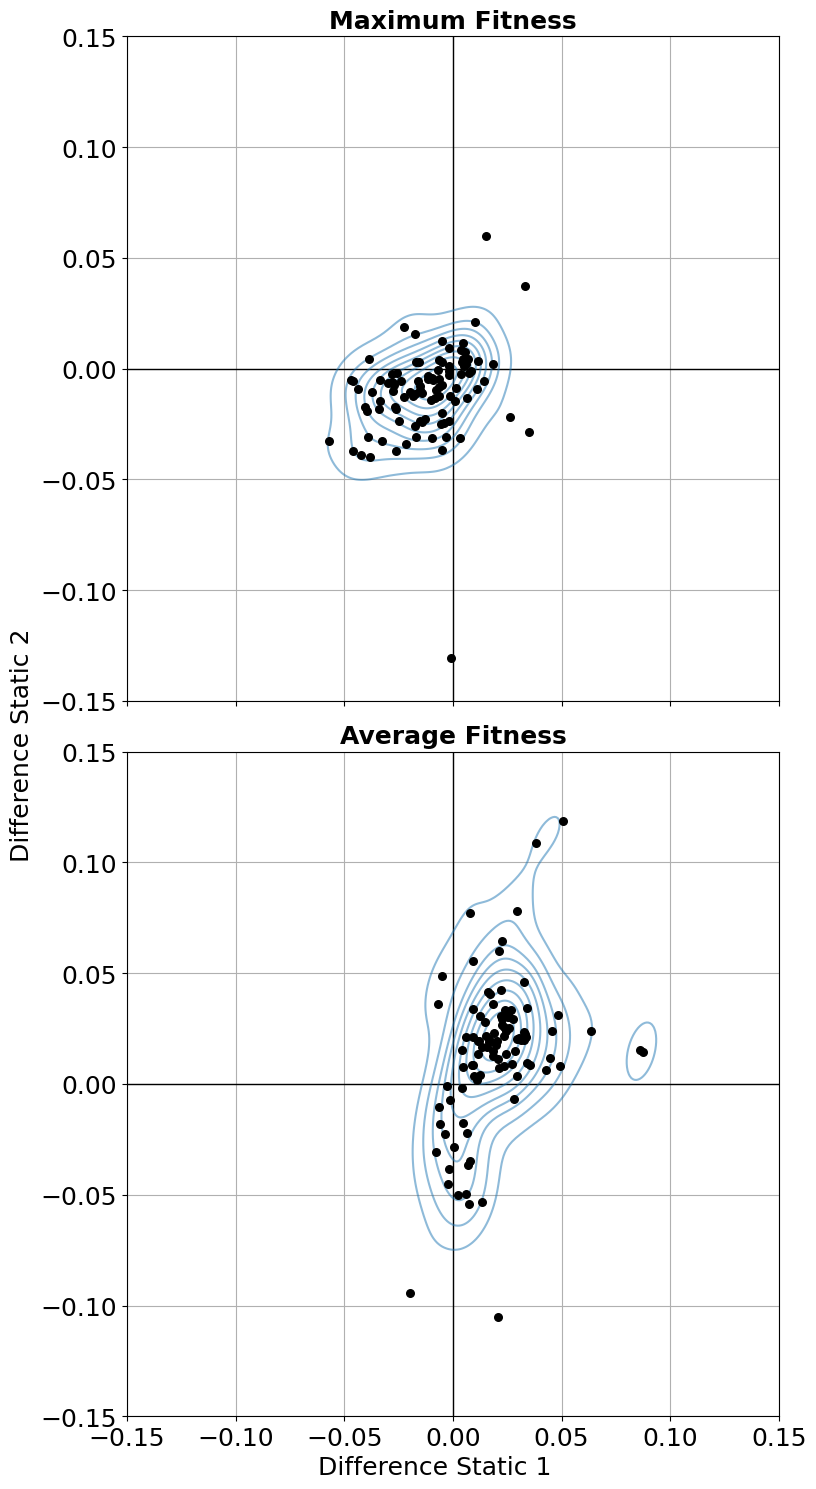

In [3]:
nrows,ncols = 2,1
scale = 7.5

fig, [ax0, ax1] = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*scale, nrows*scale), sharex=True, sharey=True)

for ax in [ax0, ax1]:
    ax.axvline(0, lw=1, color="black", zorder=1, alpha=1)
    ax.axhline(0, lw=1, color="black", zorder=1, alpha=1)

sns.kdeplot(x = maxxs, y = maxys, ax=ax0,fill=False,thresh=0.1,zorder=1,alpha=0.5)
ax0.scatter(maxxs,maxys,marker="o", color="black", s=30)

sns.kdeplot(x = avexs, y = aveys, ax=ax1,fill=False,thresh=0.1,zorder=1,alpha=0.5)
ax1.scatter(avexs,aveys,marker="o", color="black", s=30)


fig.supxlabel('Difference Static 1', fontsize = 18)
fig.text(
    -0.05,       # x-position in figure coordinates (0=left, 1=right)
    0.5,        # y-position in figure coordinates (0=bottom, 1=top)
    'Difference Static 2',
    va='center',
    ha='center',
    rotation='vertical',
    fontsize=18
)

ax0.set_title("Maximum Fitness", weight="bold", fontsize=18)
ax1.set_title("Average Fitness", weight="bold", fontsize=18)

ax0.set_xlim(-0.15, 0.15)
ax1.set_ylim(-0.15, 0.15)

for ax in [ax0, ax1]:
    ax.grid()
    ax.set_axisbelow(True)

plt.tight_layout()
ax0.tick_params(axis='both', which='major', labelsize=18)
ax1.tick_params(axis='both', which='major', labelsize=18)
plt.show()
#plt.savefig('main_scatters_diff_rules.pdf', format='pdf',bbox_inches='tight')
plt.style.use('default')

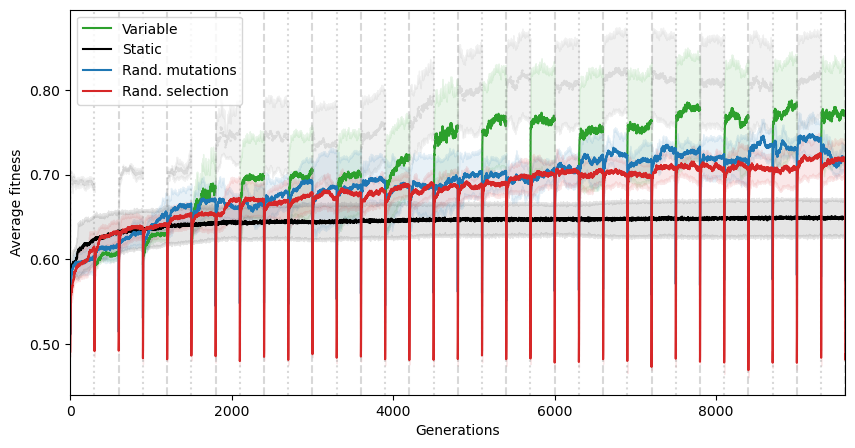

In [4]:
#Comparing the effect of random mutations and random selection to the effect of environmental variability

def format_yticks(tick, _):
        return f"{tick:.2f}"

exp_type1 = "mut_blast"
exp_type2 = "fit_blast"

root="~/CA_GRN_results/detailed_save/"
labels=["Variable","Static","Rand. mutations","Rand. selection"]
colors = ["C2","black","C0","C3"]
z_value = 1.96  # For a 95% confidence interval

season_len = 300
metric = "avefits"
rules = [102]
seed_ints = [69904,149796]
num_reps = 5

for rule in rules:

    vari_maxs=[np.loadtxt(os.path.expanduser(root+f"variable/stats_{season_len}_{rule}-{rule}_{69904}-{149796}_{i+1}_{metric}.txt")) for i in range(num_reps)]
    vari_maxs=[v[:9899] for v in vari_maxs] #for sanity

    all_maxs=helper.get_fits_alt([rule,rule], seed_ints, metric, root, season_len, num_reps, exp_type=exp_type1)
    all_maxs=np.array(all_maxs)
    all_maxs2=helper.get_fits_alt([rule,rule], seed_ints, metric, root, season_len, num_reps, exp_type=exp_type2)
    all_maxs2=np.array(all_maxs2)

    #put together with color
    m=vari_maxs 
    mean1 = np.mean(m, axis=0)
    stderr1 = np.std(m, axis=0) / np.sqrt(num_reps)
    season1, season2, gens1, gens2 = helper.chunker_plotting(mean1, season_len = 300)
    season1_std, season2_std, _, _ = helper.chunker_plotting(stderr1, season_len = 300)
    
    fig, ax=plt.subplots(nrows=1,ncols=1, figsize=(10, 5),sharex=True) #sharey=True)
    
    for i in range(len(gens1)):
        ax.plot(gens1[i], season1[i],":",color="gray",alpha=0.2)
        ax.fill_between(gens1[i], season1[i] - season1_std[i], season1[i] + season1_std[i], alpha=0.1,color="gray")
        if i == 0:
            ax.plot(gens2[i], season2[i],color="C2",label="Variable")
        else:
            ax.plot(gens2[i], season2[i],color="C2")
        ax.fill_between(gens2[i], season2[i] - season2_std[i], season2[i] + season2_std[i], alpha=0.1,color="C2")
    
    for j in range(0, len(mean1), season_len):
        if j % (season_len * 2) == 0:
            ax.axvline(j, linestyle="--", color="gray", alpha=0.3)
        else:
            ax.axvline(j, linestyle=":", color="gray", alpha=0.3)
    
    #put it together with above
    for i,m in enumerate(all_maxs[1:]):
        mean1 = np.mean(m, axis=0)
        stderr1 = np.std(m, axis=0) / np.sqrt(num_reps)
        ci_upper = mean1 + z_value * stderr1
        ci_lower = mean1 - z_value * stderr1
        ax.fill_between(range(len(mean1)), ci_lower, ci_upper, alpha=0.1, color = colors[1:][i])
        ax.plot(mean1, "-", label=labels[1:][i], color = colors[1:][i])
    mean1 = np.mean(all_maxs2[2], axis=0)
    stderr1 = np.std(all_maxs2[2], axis=0) / np.sqrt(num_reps)
    ci_upper = mean1 + z_value * stderr1
    ci_lower = mean1 - z_value * stderr1
    
    ax.fill_between(range(len(mean1)), ci_lower, ci_upper, alpha=0.1, color = colors[-1])
    ax.plot(mean1, "-", label=labels[-1], color = colors[-1])
    plt.xlim(0,9600)
    plt.xlabel("Generations")
    plt.ylabel("Average fitness")

    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_yticks))
    plt.legend()
    plt.show()


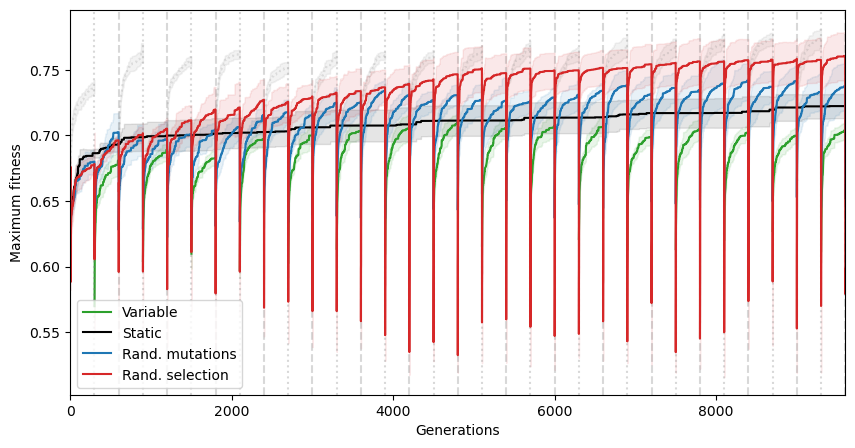

In [5]:
#Comparing the effect of random mutations and random selection to the effect of environmental variability

metric = "maxfits"
rules = [150]
seed_ints = [69904,149796]
num_reps = 5

for rule in rules:

    vari_maxs=[np.loadtxt(os.path.expanduser(root+f"variable/stats_{season_len}_{rule}-{rule}_{69904}-{149796}_{i+1}_{metric}.txt")) for i in range(num_reps)]
    vari_maxs=[v[:9899] for v in vari_maxs] #for sanity

    all_maxs=helper.get_fits_alt([rule,rule], seed_ints, metric, root, season_len, num_reps, exp_type=exp_type1)
    all_maxs=np.array(all_maxs)
    all_maxs2=helper.get_fits_alt([rule,rule], seed_ints, metric, root, season_len, num_reps, exp_type=exp_type2)
    all_maxs2=np.array(all_maxs2)

    #put together with color
    m=vari_maxs 
    mean1 = np.mean(m, axis=0)
    stderr1 = np.std(m, axis=0) / np.sqrt(num_reps)
    season1, season2, gens1, gens2 = helper.chunker_plotting(mean1, season_len = 300)
    season1_std, season2_std, _, _ = helper.chunker_plotting(stderr1, season_len = 300)
    
    fig, ax=plt.subplots(nrows=1,ncols=1, figsize=(10, 5),sharex=True) #sharey=True)
    
    for i in range(len(gens1)):
        ax.plot(gens1[i], season1[i],":",color="gray",alpha=0.2)
        ax.fill_between(gens1[i], season1[i] - season1_std[i], season1[i] + season1_std[i], alpha=0.1,color="gray")
        if i == 0:
            ax.plot(gens2[i], season2[i],color="C2",label="Variable")
        else:
            ax.plot(gens2[i], season2[i],color="C2")
        ax.fill_between(gens2[i], season2[i] - season2_std[i], season2[i] + season2_std[i], alpha=0.1,color="C2")
    
    for j in range(0, len(mean1), season_len):
        if j % (season_len * 2) == 0:
            ax.axvline(j, linestyle="--", color="gray", alpha=0.3)
        else:
            ax.axvline(j, linestyle=":", color="gray", alpha=0.3)
    
    #put it together with above
    for i,m in enumerate(all_maxs[1:]):
        mean1 = np.mean(m, axis=0)
        stderr1 = np.std(m, axis=0) / np.sqrt(num_reps)
        ci_upper = mean1 + z_value * stderr1
        ci_lower = mean1 - z_value * stderr1
        ax.fill_between(range(len(mean1)), ci_lower, ci_upper, alpha=0.1, color = colors[1:][i])
        ax.plot(mean1, "-", label=labels[1:][i], color = colors[1:][i])
    mean1 = np.mean(all_maxs2[2], axis=0)
    stderr1 = np.std(all_maxs2[2], axis=0) / np.sqrt(num_reps)
    ci_upper = mean1 + z_value * stderr1
    ci_lower = mean1 - z_value * stderr1
    
    ax.fill_between(range(len(mean1)), ci_lower, ci_upper, alpha=0.1, color = colors[-1])
    ax.plot(mean1, "-", label=labels[-1], color = colors[-1])
    plt.xlim(0,9600)
    plt.xlabel("Generations")
    plt.ylabel("Maximum fitness")

    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_yticks))
    plt.legend()
    plt.show()


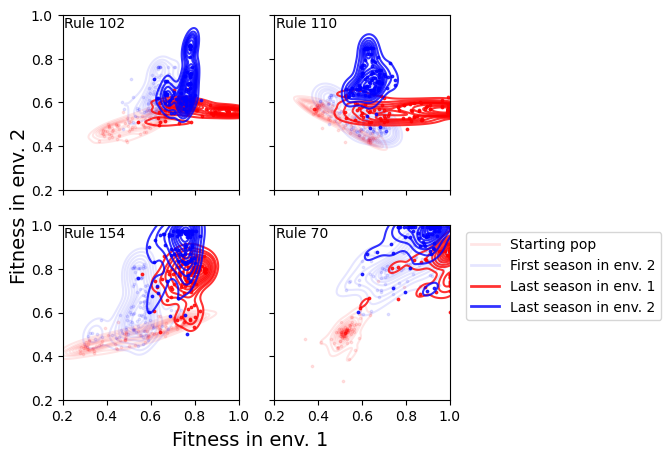

In [6]:
#Checking fitness distribution of individuals with respect to both environments over the evolutionary simulation

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

root="~/scratch/non_detailed_save/alternative_input"
num_repeats=15
pop_size = 1000

nrows,ncols = 2,2
scale = 2.5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*scale, nrows*scale), sharex=True, sharey=True)
axes = axes.flatten()

rules = [102, 110, 154, 70]
rep_nums = [1, 7, 7, 9]

ind_count = 10
for j in range(len(rules)):

    RULE = rules[j]
    
    fits=[np.loadtxt(os.path.expanduser(root+f"/stats_300_{RULE}-{RULE}_69904-149796_{i+1}_both_fits.txt")) for i in range(num_repeats)]
    fits = np.array(fits)
    num_gens = int(fits.shape[1]/2/pop_size)
    fits = fits.reshape(num_repeats, num_gens, 2, pop_size)

    fits_alt=[np.loadtxt(os.path.expanduser(root+f"/stats_300_{RULE}-{RULE}_69904-149796_{i+1}_both_fits_alt.txt")) for i in range(num_repeats)]
    fits_alt = np.array(fits_alt)
    num_gens = int(fits_alt.shape[1]/2/pop_size)
    fits_alt = fits_alt.reshape(num_repeats, num_gens, 2, pop_size)

    #getting which target is currently used
    season_turn_len = 3 #at gen == 300, curr is 1
    r = rep_nums[j]

    #Get x axis values
    arr1=fits[r][:,0,::ind_count]
    arr2=fits_alt[r][:,0,::ind_count]
    season1 = [arr1[i:i + season_turn_len] for i in range(0, len(arr1), season_turn_len)]
    season2 = [arr2[i:i + season_turn_len] for i in range(0, len(arr2), season_turn_len)]
    interleaved_chunks = []
    for i in range(len(season1)):
        if i % 2 == 0:
            interleaved_chunks.append(season1[i])
        else:
            interleaved_chunks.append(season2[i])
    f1 = np.concatenate(interleaved_chunks)

    #Get y axis values
    arr1=fits_alt[r][:,1,::ind_count]
    arr2=fits[r][:,1,::ind_count]
    season1 = [arr1[i:i + season_turn_len] for i in range(0, len(arr1), season_turn_len)]
    season2 = [arr2[i:i + season_turn_len] for i in range(0, len(arr2), season_turn_len)]
    interleaved_chunks = []
    for i in range(len(season1)):
        if i % 2 == 0:
            interleaved_chunks.append(season1[i])
        else:
            interleaved_chunks.append(season2[i])
    f2 = np.concatenate(interleaved_chunks)

    ngens, ninds = f1.shape
    seasonlen = 3
    colors = [Blues(i/ngens) if (i // seasonlen) % 2 == 0 else Reds(i/ngens)  for i in range(ngens) for j in range(ninds)]
    colors = np.array(colors)
    colors[-100:,:] = 1

    env1_start = np.arange(0,10_000,100)[::3][::2]/100 #first env starts ->if +1 100 gens in
    env1_start = env1_start.astype(int)
    env2_start =np.arange(0,10_000,100)[::3][1::2]/100 #second env starts
    env2_start = env2_start.astype(int)
    env1_end =env2_start - 1 #first env ends, -1 if +1 for starts
    env2_end =env1_start - 1 #second env ends

    cmap = plt.get_cmap('viridis')
    ints=[env1_start[0],env2_start[0]+1,env1_end[-1], env2_end[-1]]

    n_lines=len(ints)
    colors = [cmap(i / n_lines) for i in range(n_lines)]
    colors=["red", "blue", "red", "blue"]
    alphas=[0.1,0.1, 0.8, 0.8]
    lss=["-","-", "-", "-"]
    for idx, i in enumerate(ints):
        axes[j].scatter(f1[i,:].flatten(), f2[i,:].flatten(),s=3, c=colors[idx],alpha=alphas[idx])
        sns.kdeplot(x = f1[i,:].flatten(), y = f2[i,:].flatten(), ax=axes[j],fill=False,thresh=0.1,zorder=1,alpha=alphas[idx], color=colors[idx], linestyles=lss[idx])

    axes[j].set_xlim(0.2,1)
    axes[j].set_ylim(0.2,1)
    axes[j].text(0.01, 0.99, f'Rule {RULE}', transform=axes[j].transAxes,
            fontsize=10, va='top', ha='left')

fig.supxlabel('Fitness in env. 1', fontsize = 14)
fig.supylabel('Fitness in env. 2', fontsize = 14)

custom_lines =[]
for i in range(len(colors)):
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2, linestyle='-', alpha=alphas[i]))

labels = [0,400, 9800, 9500]
labels = ["Starting pop", "First season in env. 2", "Last season in env. 1", "Last season in env. 2"]
plt.legend(custom_lines, labels, bbox_to_anchor=(1.05, 1))

#plt.savefig("2dfits.pdf", bbox_inches="tight")
plt.show()